# Interactive plot for the parametric function:

$
\begin{cases}
\large x(t)=\cos(2t)-sin(2t) \\
\large y(t)=\sin(2t)-sin(t)
\end{cases}
$

$\large \text{with } 0 \le t \le 2\pi$

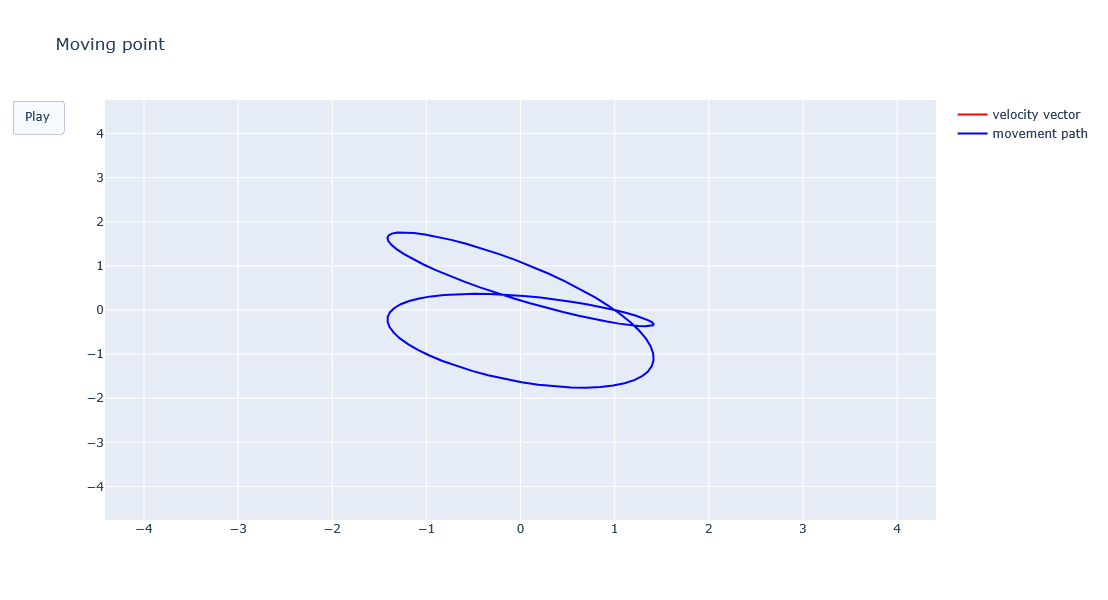

In [36]:
#-----------------------------------------------------------------------------#
#  Imports                                                                    #      
#-----------------------------------------------------------------------------#
import plotly.graph_objects as go
import numpy as np

#-----------------------------------------------------------------------------#
#  Input values and math functions                                            #      
#-----------------------------------------------------------------------------#
# Parameter range
t_min = 0
t_max = 2 * np.pi

# Amount of steps for entire function curve
curve_steps = 100

# Amount of steps for moving point
move_point_steps = 750

# Size of white space between curves and plot border
white_space = 3

def plot_func(t):
    """Calculate position and velocity of moving point (that traces out the curve)."""
    px = np.cos(2 * t) - np.sin(2 * t)
    py = np.sin(2 * t) - np.sin(t)
    vx = -2 * np.sin(2 * t) - 2 * np.cos(2 * t)
    vy = 2 * np.cos(2 * t) - np.cos(t)
    return px, py, vx, vy


#-----------------------------------------------------------------------------#
#  Figure setup                                                               #      
#-----------------------------------------------------------------------------#
# Calculate curve data
t_curve = np.linspace(0, 2 * np.pi, curve_steps)
t_point = np.linspace(0, 2 * np.pi, move_point_steps)
px, py, vx, vy = plot_func(t_curve)

# Calculate coordinates for end point of velocity vector
pxx, pyy, vxx, vyy = plot_func(t_point)
vel_vec_end_x = pxx + vxx
vel_vec_end_y = pyy + vyy

# Calculate plot figure limits
x_min = np.min(px) - white_space
x_max = np.max(px) + white_space
y_min = np.min(py) - white_space
y_max = np.max(py) + white_space

# Contruct play button
animate_func_args = [
    None,
    {
        "frame": {
            "duration": 10,
            "redraw": False
        },
     "fromcurrent": True,
     "transition": {"duration": 10}
    }
] 
play_button = go.layout.updatemenu.Button(
    label="Play",
    method="animate",
    args=animate_func_args,
)

# Construct control menu with buttons
control_menu = go.layout.Updatemenu(
    type="buttons",
    buttons=[play_button],
)

# Construct layout
layout = go.Layout(
    width=600,
    height=600,
    xaxis={
        "range": [x_min, x_max],
        "autorange": False,
        "zeroline": False,
    },
    yaxis={
        "range": [y_min, y_max],
        "autorange": False,
        "zeroline": False,
    },
    title={"text": "Moving point"},
    hovermode="closest",
    updatemenus=[control_menu],
) 

# Construct a velocity vector trace for each time point
vel_vect_traces = []
for idx in range(move_point_steps):                
    trace = go.Scatter(
        x=[pxx[idx], vel_vec_end_x[idx]],
        y=[pyy[idx], vel_vec_end_y[idx]],
        mode="lines",
        line={
            "color": "red",
            "width": 2,
        },
    )
    frame = go.Frame(data=[trace])
    vel_vect_traces.append(frame)

# Create trace for curve path
curve_trace = go.Scatter(
    x=px,
    y=py,
    name="movement path",
    mode="lines",
    line={
        "width": 2,
        "color": "blue",
    },
)

# Create initialization trace for velocity vector
init_vel_vect_trace = go.Scatter(
    x=[pxx[0]],
    y=[pyy[0]],
    name="velocity vector",
    mode="lines",
    line={
        "width": 2,
        "color": "red",
    },
)

# Create figure
fig = go.Figure(
    data=[init_vel_vect_trace, curve_trace],
    layout=layout,
    frames=vel_vect_traces,
)


#-----------------------------------------------------------------------------#
#  Launch figure                                                              #      
#-----------------------------------------------------------------------------#
fig.show()
